In [1]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import geotherm_calculator as gc
import planetary_grid_reader as pgr
import habitability_calculator as hc

from tqdm import tqdm

from astropy import constants as const
from matplotlib.patches import Patch

# Librería IAPWS para propiedades del agua
from iapws import IAPWS95
from iapws.iapws97 import IAPWS97
from iapws.iapws08 import _Tf, _Tb, _Triple
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure

In [2]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

In [3]:
mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(mineral_objects=mineral_objects)
upper = rocks['upper']

## Zona de Habitabilidad - Kopparapu et al. (2013)

In [ ]:
# Parámetros del Sol
T_eff_sun = 5780.0  # K
L_star_sun = const.L_sun.value  # W

# Calcular distancias de los límites para el Sol usando el módulo hc
distances_kopparapu = {}
for limit_name in hc.HZ_LIMITS_KOPPARAPU_2013:
    distances_kopparapu[limit_name] = hc.hz_distance(T_eff_sun, L_star_sun, limit_name)

print("="*70)
print("ZONA DE HABITABILIDAD - Sol (Kopparapu et al. 2013)")
print("="*70)
print(f"\nParámetros estelares:")
print(f"  T_eff = {T_eff_sun} K")
print(f"  L = {L_star_sun/const.L_sun.value:.2f} L_sun")
print(f"\nLímites CONSERVADORES:")
print(f"  Moist Greenhouse (interno):  {distances_kopparapu['Moist Greenhouse']:.4f} AU")
print(f"  Runaway Greenhouse (interno): {distances_kopparapu['Runaway Greenhouse']:.4f} AU")
print(f"  Maximum Greenhouse (externo): {distances_kopparapu['Maximum Greenhouse']:.4f} AU")
print(f"\nLímites OPTIMISTAS:")
print(f"  Recent Venus (interno):       {distances_kopparapu['Recent Venus']:.4f} AU")
print(f"  Early Mars (externo):         {distances_kopparapu['Early Mars']:.4f} AU")
print(f"\nZona Habitable Conservadora:  {distances_kopparapu['Moist Greenhouse']:.4f} - {distances_kopparapu['Maximum Greenhouse']:.4f} AU")
print(f"Zona Habitable Optimista:     {distances_kopparapu['Recent Venus']:.4f} - {distances_kopparapu['Early Mars']:.4f} AU")
print("="*70)

ZONA DE HABITABILIDAD - Sol (Kopparapu et al. 2013)

Parámetros estelares:
  T_eff = 5780.0 K
  L = 1.00 L_sun

Límites CONSERVADORES:
  Moist Greenhouse (interno):  0.9928 AU
  Runaway Greenhouse (interno): 0.9813 AU
  Maximum Greenhouse (externo): 1.6886 AU

Límites OPTIMISTAS:
  Recent Venus (interno):       0.7503 AU
  Early Mars (externo):         1.7658 AU

Zona Habitable Conservadora:  0.9928 - 1.6886 AU
Zona Habitable Optimista:     0.7503 - 1.7658 AU


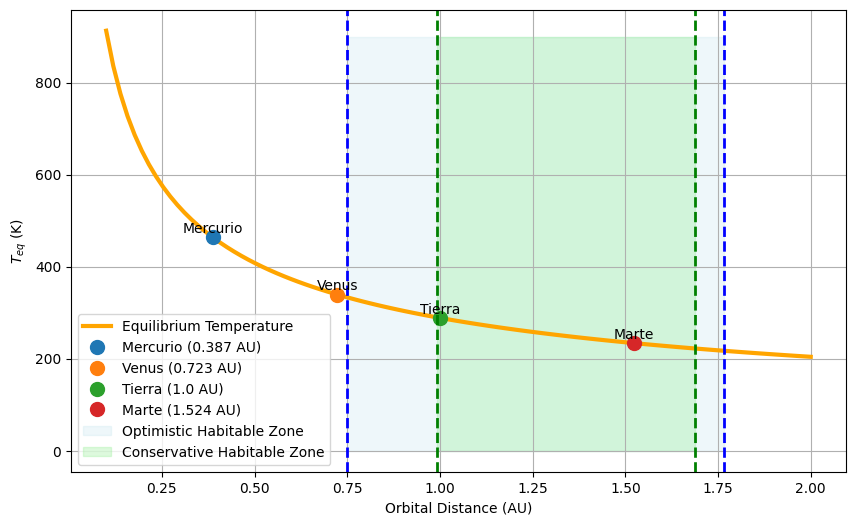

In [6]:
ds = np.linspace(0.1, 2.0, 100)
T_eqs = [hc.T_eq(distance_AU=d) for d in ds]

planets = {
    'Mercurio': 0.387,
    'Venus': 0.723,
    'Tierra': 1.000,
    'Marte': 1.524,
}

plt.figure(figsize=(10, 6))
plt.plot(ds, T_eqs, 'orange', linewidth=3, label='Equilibrium Temperature')
for planet, d in planets.items():
    T_eq_planet = hc.T_eq(distance_AU=d)
    plt.plot(d, T_eq_planet, 'o', markersize=10, label=f'{planet} ({d} AU)')
    plt.text(d, T_eq_planet + 10, planet, fontsize=10, ha='center')
plt.axvline(distances_kopparapu['Moist Greenhouse'], color='green', linestyle='--', linewidth=2)
plt.axvline(distances_kopparapu['Maximum Greenhouse'], color='green', linestyle='--', linewidth=2)

plt.axvline(distances_kopparapu['Recent Venus'], color='blue', linestyle='--', linewidth=2)
plt.axvline(distances_kopparapu['Early Mars'], color='blue', linestyle='--', linewidth=2)
plt.fill_betweenx([0, 900], distances_kopparapu['Recent Venus'], distances_kopparapu['Early Mars'], 
                 color='lightblue', alpha=0.2, label='Optimistic Habitable Zone')
plt.fill_betweenx([0, 900], distances_kopparapu['Moist Greenhouse'], distances_kopparapu['Maximum Greenhouse'], 
                 color='lightgreen', alpha=0.3, label='Conservative Habitable Zone')

plt.xlabel('Orbital Distance (AU)')
plt.ylabel('$T_{eq}$ (K)')
plt.legend()
plt.grid(True)
plt.show()

## Indice y Volumen de Habitabilidad 3D

### Volumen de Habitabilidad ($V_{3D}$)

In [5]:
def Volume3D(d,
             rocks,
             R_planet,
             M_planet,
             qs,
             P_top=1e5,
             ):
    

    T_surf = hc.T_eq(d, tau= 0.22)

    df_geotherm = gc.calculate_geotherm(
        rocks=rocks,
        q_s=qs,           # 65 mW/m²
        z_max=30e3,         # 10 km 
        dz=100.0,           
        R_planet=R_planet,
        M_total=M_planet,
        boundaries=gc.scale_layer_boundaries(R_planet=R_planet),
        T_top=T_surf,
        P_top=P_top,
        A_surface=2.5e-6,
        h_r=10e3
    )

    liquid_zone_data = hc.find_liquid_zone(df_geotherm, salinity=0.0, information=False)
    
    if liquid_zone_data['liquid_zone'] is not None:
        habitable_zone_data = hc.find_habitable_zone(liquid_zone_data['indices'], df_geotherm, information=False)
        
        liq_top = liquid_zone_data['liquid_zone'][0]
        liq_bot = liquid_zone_data['liquid_zone'][-1]
        liq_thickness = (liq_bot - liq_top)

        volume_liquid = (4/3) * np.pi * (Re**3 - (Re - liq_thickness)**3)

        if habitable_zone_data is not None and habitable_zone_data['habitable_zone'] is not None:
            bio_top = habitable_zone_data['habitable_zone'][0]
            bio_bot = habitable_zone_data['habitable_zone'][-1]
            bio_thickness = (bio_bot - bio_top)

            volume_habitable = (4/3) * np.pi * (Re**3 - (Re - bio_thickness)**3)
        else:
            bio_thickness = 0.0
            volume_habitable = 0.0

    else:
        liq_thickness = 0.0
        bio_thickness = 0.0
        volume_liquid = 0.0
        volume_habitable = 0.0

    return {
        'liquid_thickness_km': liq_thickness / 1000,
        'habitable_thickness_km': bio_thickness / 1000,
        'liquid_volume_km3': volume_liquid / 1e9,
        'habitable_volume_km3': volume_habitable / 1e9,
    }

In [6]:
V_3D = Volume3D(1, 
                rocks,
                Re,
                Me,
                qs=65e-3)

liquid_volume_earth = V_3D.get('liquid_volume_km3', 0.0)
habitable_volume_earth = V_3D.get('habitable_volume_km3', 0.0)

print(f"\n🌍 VALORES PARA LA TIERRA ACTUAL:")
print(f"Volumen de Zona de Aguabilidad: {liquid_volume_earth:.2e} km³ = {liquid_volume_earth/to:.2f} to")
print(f"Volumen de Zona Habitable: {habitable_volume_earth:.2e} km³ = {habitable_volume_earth/to:.2f} to ")


🌍 VALORES PARA LA TIERRA ACTUAL:
Volumen de Zona de Aguabilidad: 3.42e+09 km³ = 2.47 to
Volumen de Zona Habitable: 1.79e+09 km³ = 1.29 to 


In [7]:
porosidad_earth = 0.1  # Suposición de porosidad del manto terrestre
liquid_volume_eff = porosidad_earth * liquid_volume_earth
habitable_volume_eff = porosidad_earth * habitable_volume_earth
print(f"Volumen de poros en la Tierra: {liquid_volume_eff:.2e} km³ = {liquid_volume_eff/to:.2f} to")
print(f"Volumen habitable efectivo en la Tierra: {habitable_volume_eff:.2e} km³ = {habitable_volume_eff/to:.2f} to")

Volumen de poros en la Tierra: 3.42e+08 km³ = 0.25 to
Volumen habitable efectivo en la Tierra: 1.79e+08 km³ = 0.13 to


## Indice de Habitabilidad 3D ($I_{3D}$)

El índice se define como:

$$I_{3D} = \frac{\int_{a_{in}}^{a_{out}} V_{hab}(a) \, da}{\Delta a}$$

donde:
- $a$ = distancia orbital en AU
- $V_{hab}(a)$ = volumen habitable del planeta a distancia $a$
- $a_{in}, a_{out}$ = límites interior y exterior de la zona habitable
- $\Delta a = a_{out} - a_{in}$ = ancho de la HZ

El índice representa el **volumen habitable promedio** que el planeta mantendría si orbitara en cualquier punto dentro de la HZ.


### Modelo simple

In [7]:
def I3D(rocks, R_planet, M_planet, qs,
        a_in, a_out, 
        N = 100):
    
    ds = np.linspace(a_in, a_out, N)

    Vhabs = []

    for d in ds:
        V_3D = Volume3D(d,
                        rocks,
                        R_planet,
                        M_planet,
                        qs)
        
        habitable_volume = V_3D.get('habitable_volume_km3', 0.0)
        Vhabs.append(habitable_volume)
    Vhabs = np.array(Vhabs)

    I3D_value = np.trapz(Vhabs, ds)
    delta_a = a_out - a_in
    I3D_normalized = I3D_value / delta_a

    return  {
        'I3D': I3D_normalized,
        'a_values': ds,
        'Vhab_values': Vhabs
    }


In [8]:
I3D_result = I3D(rocks, Re, Me, qs=65e-3,
                 a_in=distances_kopparapu['Moist Greenhouse'],
                 a_out=distances_kopparapu['Maximum Greenhouse'],
                 N=100)

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Santiago\AppData\Local\Temp\ipykernel_21868\1030613787.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$V_{hab} [V_{hab, \oplus}]$")


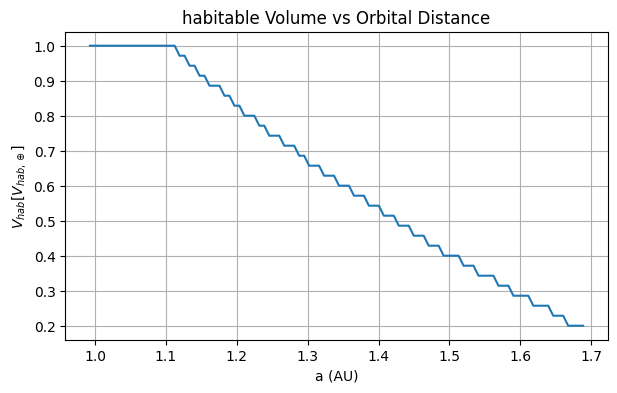

I_3D para Tierra: 1.122e+09 km³


In [9]:
plt.figure(figsize=(7,4))
plt.plot(I3D_result['a_values'], I3D_result['Vhab_values']/habitable_volume_earth)
plt.xlabel("a (AU)")
plt.ylabel("$V_{hab} [V_{hab, \oplus}]$")
plt.title("habitable Volume vs Orbital Distance")
plt.grid()
plt.show()
print(f"I_3D para Tierra: {I3D_result['I3D']:.3e} km³")

### Modelo mas complejo ($M_p, a, q_s$)

## Escalado de la presión atmosférica superficial

Para planetas rocosos con composición similar a la Tierra, la presión atmosférica superficial $p_0$ puede estimarse a partir del peso total de la atmósfera por unidad de área:

$$
p_0 = \frac{M_{\mathrm{atm}}\, g}{4\pi R^2},
$$

donde $M_{\mathrm{atm}}$ es la masa total de la atmósfera, $g$ la aceleración gravitacional superficial y $R$ el radio planetario.


Asumimos que el planeta conserva una atmósfera de composición terrestre y que la fracción atmosférica se mantiene constante al escalar la masa planetaria, es decir:

$$
\frac{M_{\mathrm{atm}}}{M_{\mathrm{planet}}} = \text{constante}.
$$

Bajo esta hipótesis se tiene:

$$
M_{\mathrm{atm}} \propto M_{\mathrm{planet}}.
$$

### Relación masa–radio

Para planetas rocosos con composición similar a la Tierra, el radio escala con la masa como (Valencia et al. 2006; Zeng et al. 2016):

$$
\frac{R}{R_\oplus} \simeq \left(\frac{M}{M_\oplus}\right)^{0.27}.
$$

La aceleración gravitacional superficial es:

$$
g = \frac{G M}{R^2},
$$

por lo que:

$$
\frac{g}{g_\oplus} =
\left(\frac{M}{M_\oplus}\right)^{1 - 2\times0.27}
=
\left(\frac{M}{M_\oplus}\right)^{0.46}.
$$

### Escalado final de la presión superficial

Sustituyendo los escalados de $M_{\mathrm{atm}}$, $g$ y $R$ en la expresión de $p_0$:

$$
p_0 \propto \frac{M\, g}{R^2}
\propto
\frac{M \cdot M^{0.46}}{M^{0.54}}
=
M^{0.92}.
$$

Por tanto, la presión atmosférica superficial escala como:

$$
\boxed{
\frac{p_0}{p_{0,\oplus}} \simeq
\left(\frac{M}{M_\oplus}\right)^{0.92}
}
$$

donde $p_{0,\oplus} = 1\ \mathrm{atm}$ es la presión superficial terrestre.

Este escalado es apropiado para planetas rocosos tipo Tierra y proporciona una parametrización físicamente consistente de la presión atmosférica superficial al explorar la dependencia de la habitabilidad con la masa planetaria.


In [52]:
def mass_to_radius(M_planet, 
                   M_ref=Me, 
                   R_ref=Re):
    """
    Masa-radio para planetas rocosos tipo Tierra.
    Válido hasta ~5-6 M⊕
    """
    gamma = 0.27
    return R_ref * (M_planet / M_ref)**gamma

def surface_pressure(M_planet,
                     M_ref=Me,
                     P0_ref=1.01325e5):
    """
    Escala la presión atmosférica superficial para planetas tipo Tierra.
    
    p0 ∝ M^0.92  (atmósfera tipo Tierra)
    """
    return P0_ref * (M_planet / M_ref)**0.92

def I_3D(M_planet, qs, rocks, a_in, a_out, N=100):
    Rp = mass_to_radius(M_planet)
    Ptop = surface_pressure(M_planet)

    ds = np.linspace(a_in, a_out, N)
    Vhabs = np.zeros_like(ds)

    for i, d in enumerate(ds):
        V_3D = Volume3D(d,
                        rocks,
                        Rp,
                        M_planet,
                        qs,
                        P_top=Ptop)
        
        habitable_volume = V_3D.get('habitable_volume_km3', 0.0)
        Vhabs[i] = habitable_volume

    I3D_value = np.trapz(Vhabs, ds)/ (a_out - a_in)
    return I3D_value

def I3D_grid(Masses, qss, rocks, a_in, a_out, N=100,
             cache_file=None, use_tqdm=True):
    
    if cache_file and os.path.exists(cache_file):
        print(f"Reloading cached I3D grid from {cache_file}...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    nM = len(Masses)
    nq = len(qss)
    I3d_grid = np.zeros((nM, nq))

    iterator = range(nM * nq)
    if use_tqdm:
        iterator = tqdm(iterator, desc="Calculating I3D grid")


    idx = 0
    for iM, Mp in enumerate(Masses):
        for iq, qs in enumerate(qss):
            I3d_grid[iM, iq] = I_3D(Mp, qs, rocks, a_in, a_out, N=N)
            print(f"I3D calculation progress: {idx+1}/{nM*nq}", end='\r')
            idx += 1

    result = {
        'mass_array': np.array(Masses),
        'qs_array': np.array(qss),
        'I3D_grid': I3d_grid,
    }

    if cache_file:
        with open(cache_file, 'wb') as f:
            pickle.dump(result, f)

    return result

def plot_I3D_heatmap(result, mass_unit='Me', cmap='viridis',
                     qs_evo = None,
                     log_scale=False):
    """
    Plotea heatmap de I3D_grid (eje x: qs, eje y: masa)
    mass_unit: 'Me' para mostrar masas en Earth masses (Mp/Me)
    """
    mass_array = result['mass_array']
    qs_array = result['qs_array']
    I3D_grid = result['I3D_grid']/habitable_volume_earth
    
    if mass_unit == 'Me':
        y_ticks = mass_array / Me
        y_label = 'M (M⊕)'
    else:
        y_ticks = mass_array
        y_label = 'M (kg)'
    
    X, Y = np.meshgrid(qs_array*1e3, y_ticks)  # qs en mW/m2 para etiqueta
    
    plt.figure(figsize=(9,5))
    if log_scale:
        plt.pcolormesh(X, Y, np.log10(I3D_grid), shading='auto', cmap=cmap)
        cbar = plt.colorbar()
        cbar.set_label('log10(I3D) [km^3]')
    else:
        plt.pcolormesh(X, Y, I3D_grid, shading='auto', cmap=cmap)
        cbar = plt.colorbar()
        cbar.set_label('$I_{3D} [V_{hab, \oplus}]$')
    
    #Tierra
    plt.scatter(65, 1.0, color='red', s=150, marker='*', edgecolors='black', linewidths=2,
                label='Tierra (65 mW/m², 1 M⊕)', zorder=10)
    plt.legend(loc='upper right', fontsize=10)

    if qs_evo is not None:
        planet_mass = 1.0
        plt.plot(qs_evo*1e3, [planet_mass]*len(qs_evo), 
                 color='cyan', linewidth=2, linestyle='--',
                 label=f'Evolución térmica ({planet_mass:.1f} M⊕)', zorder=9)
        
    plt.xlabel('q_s (mW/m²)')
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

<>:106: SyntaxWarning: invalid escape sequence '\o'
<>:106: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Santiago\AppData\Local\Temp\ipykernel_5936\3294443337.py:106: SyntaxWarning: invalid escape sequence '\o'
  cbar.set_label('$I_{3D} [V_{hab, \oplus}]$')


In [53]:
Masses = np.linspace(0.5*Me, 5*Me, 10)  # 0.1 a 5 Earth masses
qss = np.linspace(20e-3, 200e-3, 10)  # 20 a 200 mW/m²
a_in = distances_kopparapu['Moist Greenhouse']
a_out = distances_kopparapu['Maximum Greenhouse']

result = I3D_grid(Masses, qss, rocks, a_in, a_out, N=50, cache_file='I3D_cache.pkl', use_tqdm=True)

Reloading cached I3D grid from I3D_cache.pkl...


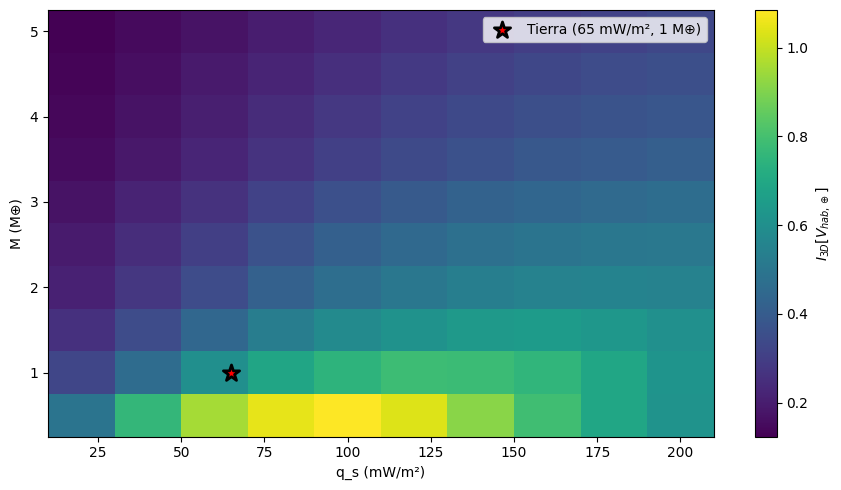

In [54]:
plot_I3D_heatmap(result)

### Camino de Evolucion Termica de la Tierra


In [58]:
planetary_grid_path = "PlanetaryGrid"
target_folder = "CMF_0.30-IMF_0.00"
planet = 'M1.00'
folder_path = os.path.join(planetary_grid_path, target_folder)

if not os.path.isdir(folder_path):
    print(f"Error: Folder '{folder_path}' not found.")
else:
    files = sorted(os.listdir(folder_path))
    tevol_files = [f for f in files if f.startswith(planet) and f.endswith('TEVOL.dat')]
    if not tevol_files:
        print(f"No TEVOL.dat files found in {folder_path}")
    else:
        for tfile in tevol_files:
            path_tevol = os.path.join(folder_path, tfile)
            data_tevol = pgr.read_tevol_dat(path_tevol)
            ts = np.array(data_tevol['#t']) /1e9
            qm = np.array(data_tevol['Qm']) 
            qss = qm / (4*np.pi*Re**2) 


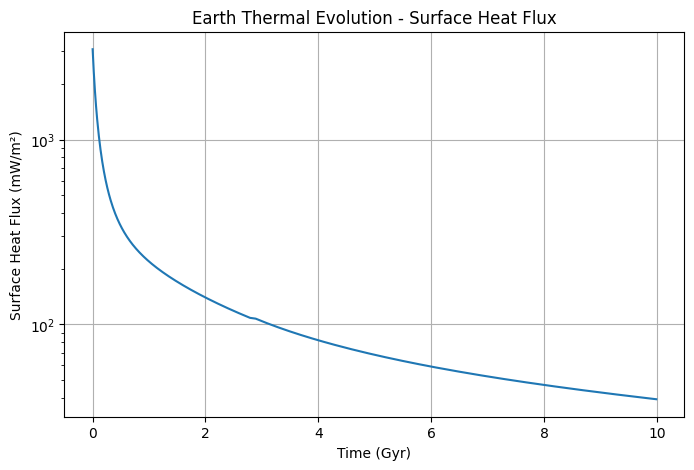

In [60]:
# Plot heat flux evolution over time
plt.figure(figsize=(8, 5))
plt.plot(ts, qss*1e3)  # Convert to mW/m²
plt.xlabel('Time (Gyr)')
plt.ylabel('Surface Heat Flux (mW/m²)')
plt.title('Earth Thermal Evolution - Surface Heat Flux')
plt.yscale('log')
plt.grid(True)
plt.show()

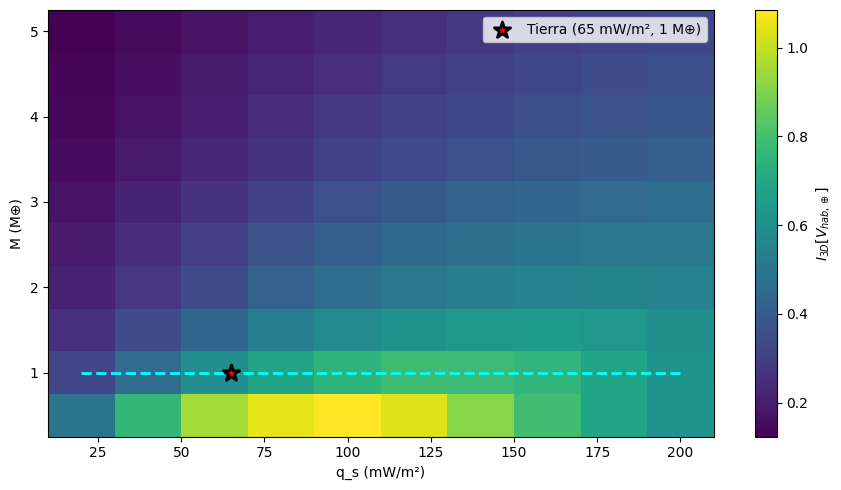

In [55]:
plot_I3D_heatmap(result, qs_evo = qss)